<a href="https://colab.research.google.com/github/flexxyyy18/DecodeLabs-Internship/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 100
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('netflix_titles.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 8807 rows × 12 columns


In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
print("Column Info:")
print("-" * 50)
df.info()

Column Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
print(f"Total Records  : {df.shape[0]:,}")
print(f"Total Features : {df.shape[1]}")
print()
print("Numeric columns  :", list(df.select_dtypes(include='number').columns))
print("Categorical cols :", list(df.select_dtypes(include='object').columns))

Total Records  : 8,807
Total Features : 12

Numeric columns  : ['release_year']
Categorical cols : ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'rating', 'duration', 'listed_in', 'description']


In [7]:
print("""
Dataset Description
-------------------
This dataset contains information about all Movies and TV Shows available on Netflix
as of mid-2021. Each row represents one title with the following features:

  - show_id       : Unique identifier for each title
  - type          : Content type — Movie or TV Show
  - title         : Name of the content
  - director      : Director(s) of the content
  - cast          : Main cast members
  - country       : Country where the content was produced
  - date_added    : Date the title was added to Netflix
  - release_year  : Original release year
  - rating        : Content rating (TV-MA, PG-13, R, etc.)
  - duration      : Duration — minutes for Movies, seasons for TV Shows
  - listed_in     : Genre categories
  - description   : Short synopsis of the content

Total titles : 8,807  (6,131 Movies | 2,676 TV Shows)
Year range   : 1925 – 2021
""")


Dataset Description
-------------------
This dataset contains information about all Movies and TV Shows available on Netflix
as of mid-2021. Each row represents one title with the following features:

  - show_id       : Unique identifier for each title
  - type          : Content type — Movie or TV Show
  - title         : Name of the content
  - director      : Director(s) of the content
  - cast          : Main cast members
  - country       : Country where the content was produced
  - date_added    : Date the title was added to Netflix
  - release_year  : Original release year
  - rating        : Content rating (TV-MA, PG-13, R, etc.)
  - duration      : Duration — minutes for Movies, seasons for TV Shows
  - listed_in     : Genre categories
  - description   : Short synopsis of the content

Total titles : 8,807  (6,131 Movies | 2,676 TV Shows)
Year range   : 1925 – 2021



In [8]:
print("Content Type Distribution:")
print(df['type'].value_counts())
print()

print("Top 10 Countries by Content Volume:")
print(df['country'].value_counts().head(10))


Content Type Distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top 10 Countries by Content Volume:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [9]:
print("Content Rating Distribution (Top 10):")
print(df['rating'].value_counts().head(10))
print()
print("Release year range:", df['release_year'].min(), "–", df['release_year'].max())

Content Rating Distribution (Top 10):
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

Release year range: 1925 – 2021


Task 2

In [10]:
print("Missing Values per Column:")
print("-" * 40)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values per Column:
----------------------------------------
            Missing Count  Missing %
director             2634      29.91
cast                  825       9.37
country               831       9.44
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


In [11]:
print(f"Duplicate rows: {df.duplicated().sum()}")
print("→ No duplicates found. No removal needed.")

Duplicate rows: 0
→ No duplicates found. No removal needed.


In [12]:
df_clean = df.copy()

# Fill missing directors, cast, country with 'Unknown'
df_clean['director'].fillna('Unknown', inplace=True)
df_clean['cast'].fillna('Unknown', inplace=True)
df_clean['country'].fillna('Unknown', inplace=True)

# Fill missing rating with mode (most common rating)
mode_rating = df_clean['rating'].mode()[0]
df_clean['rating'].fillna(mode_rating, inplace=True)

# Fill missing duration with mode
mode_duration = df_clean['duration'].mode()[0]
df_clean['duration'].fillna(mode_duration, inplace=True)

# Drop the 10 rows with missing date_added (very small, safe to drop)
df_clean.dropna(subset=['date_added'], inplace=True)

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nRows after cleaning: {len(df_clean):,} (removed {len(df) - len(df_clean)} rows)")

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Rows after cleaning: 8,797 (removed 10 rows)


In [13]:
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip())
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month
df_clean['month_name'] = df_clean['date_added'].dt.strftime('%b')

print("Date column formatted successfully.")
df_clean[['date_added', 'year_added', 'month_added', 'month_name']].head()

Date column formatted successfully.


,date_added,year_added,month_added,month_name
0,2021-09-25,2021,9,Sep
1,2021-09-24,2021,9,Sep
2,2021-09-24,2021,9,Sep
3,2021-09-24,2021,9,Sep
4,2021-09-24,2021,9,Sep


In [14]:
# Movies → minutes, TV Shows → number of seasons
df_clean['duration_value'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)

print("Movie duration (minutes) — sample:")
print(df_clean[df_clean['type']=='Movie'][['title','duration','duration_value']].head(3))
print()
print("TV Show duration (seasons) — sample:")
print(df_clean[df_clean['type']=='TV Show'][['title','duration','duration_value']].head(3))

Movie duration (minutes) — sample:
                              title duration  duration_value
0              Dick Johnson Is Dead   90 min            90.0
6  My Little Pony: A New Generation   91 min            91.0
7                           Sankofa  125 min           125.0

TV Show duration (seasons) — sample:
                   title   duration  duration_value
1          Blood & Water  2 Seasons             2.0
2              Ganglands   1 Season             1.0
3  Jailbirds New Orleans   1 Season             1.0


In [15]:
df_clean['primary_country'] = df_clean['country'].str.split(',').str[0].str.strip()

print("Data cleaning complete. Summary:")
print(f"  Rows            : {len(df_clean):,}")
print(f"  Missing values  : {df_clean.isnull().sum().sum()}")
print(f"  Duplicates      : {df_clean.duplicated().sum()}")
print(f"  New columns     : year_added, month_added, month_name, duration_value, primary_country")
df_clean.head(3)

Data cleaning complete. Summary:
  Rows            : 8,797
  Missing values  : 0
  Duplicates      : 0
  New columns     : year_added, month_added, month_name, duration_value, primary_country


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_value,primary_country
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Sep,90.0,United States
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,Sep,2.0,South Africa
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Sep,1.0,Unknown


Task 3

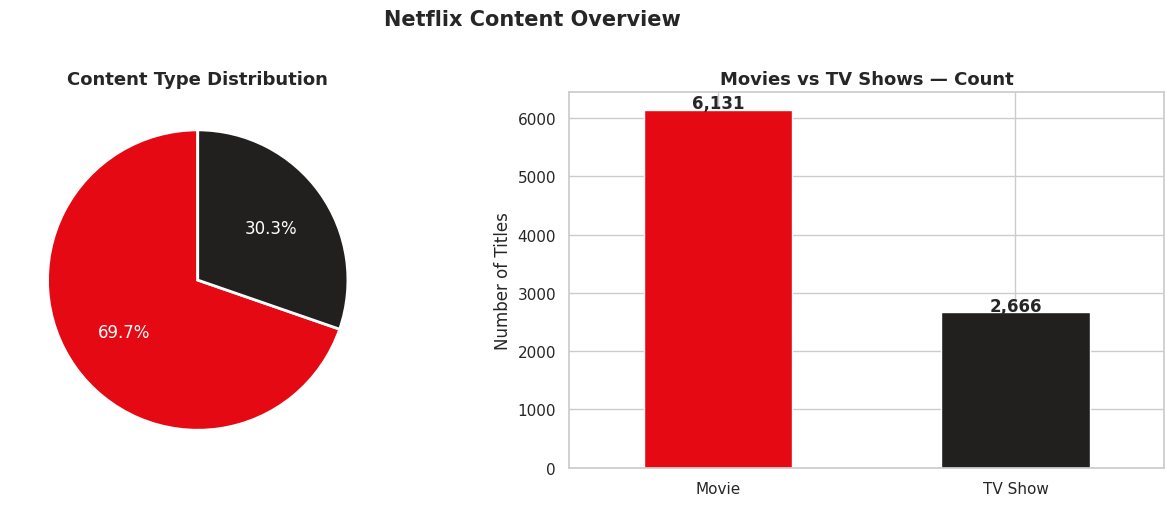

Insight: Netflix has ~2.3x more Movies than TV Shows.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
type_counts = df_clean['type'].value_counts()
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#E50914','#221F1F'], startangle=90,
            textprops={'color':'white','fontsize':12}, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Content Type Distribution', fontsize=13, fontweight='bold')

# Bar chart
type_counts.plot(kind='bar', ax=axes[1], color=['#E50914','#221F1F'], edgecolor='white', width=0.5)
axes[1].set_title('Movies vs TV Shows — Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Titles')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(type_counts):
    axes[1].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Netflix Content Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Insight: Netflix has ~2.3x more Movies than TV Shows.")

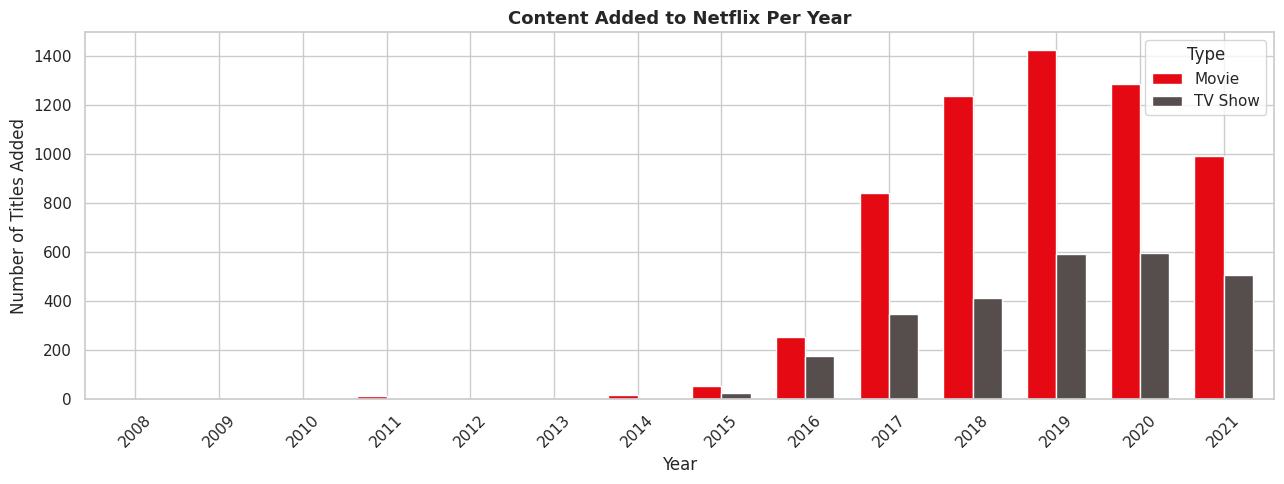

Insight: Netflix saw massive content growth from 2016 to 2019, peaking in 2019.


In [17]:
yearly = df_clean.groupby(['year_added','type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
yearly.plot(kind='bar', ax=ax, color=['#E50914','#564d4d'], edgecolor='white', width=0.7)
ax.set_title('Content Added to Netflix Per Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
plt.tight_layout()
plt.show()

print("Insight: Netflix saw massive content growth from 2016 to 2019, peaking in 2019.")

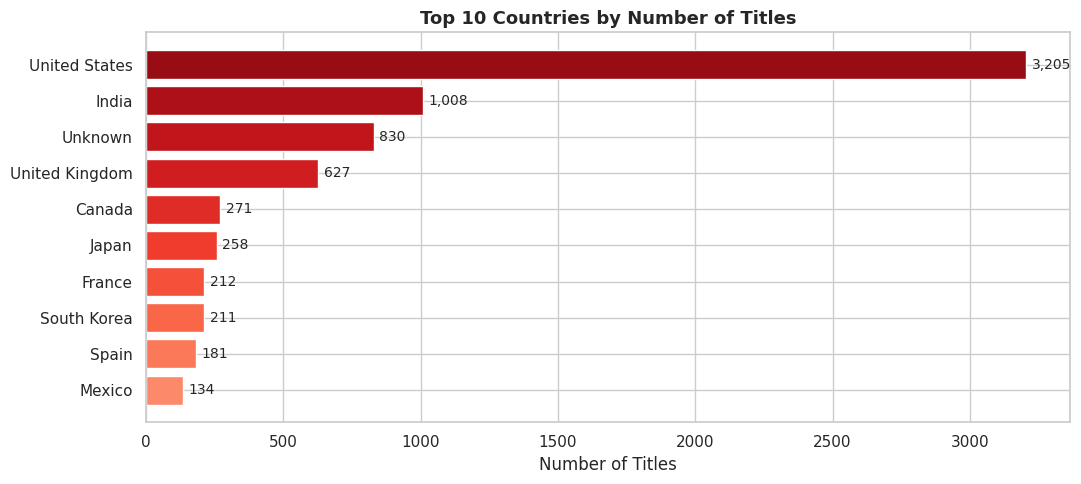

Insight: The United States dominates with 2,818 titles, followed by India (972) and UK (419).


In [18]:
top_countries = df_clean['primary_country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=plt.cm.Reds(np.linspace(0.4, 0.9, 10)), edgecolor='white')
ax.set_title('Top 10 Countries by Number of Titles', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("Insight: The United States dominates with 2,818 titles, followed by India (972) and UK (419).")

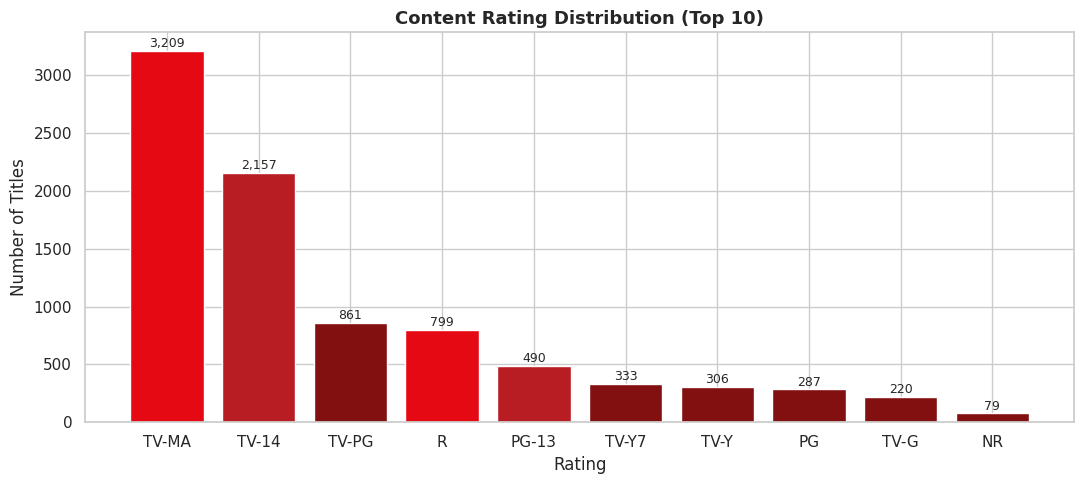

Insight: TV-MA (mature audiences) is the most common rating, showing Netflix targets adult viewers.


In [19]:
rating_counts = df_clean['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#E50914' if r in ['TV-MA','R'] else '#B81D24' if r in ['TV-14','PG-13'] else '#831010'
          for r in rating_counts.index]
bars = ax.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='white')
ax.set_title('Content Rating Distribution (Top 10)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Insight: TV-MA (mature audiences) is the most common rating, showing Netflix targets adult viewers.")

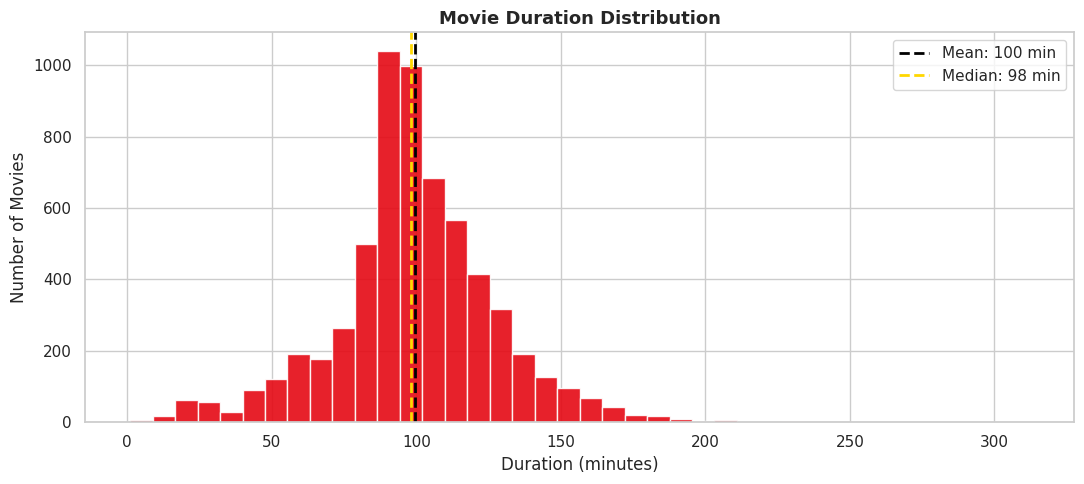

Insight: Most Netflix movies run between 80–120 minutes. Mean = 100 min.


In [20]:
movies = df_clean[df_clean['type'] == 'Movie'].copy()

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(movies['duration_value'].dropna(), bins=40, color='#E50914', edgecolor='white', alpha=0.9)
ax.axvline(movies['duration_value'].mean(), color='black', linestyle='--', linewidth=2,
           label=f"Mean: {movies['duration_value'].mean():.0f} min")
ax.axvline(movies['duration_value'].median(), color='gold', linestyle='--', linewidth=2,
           label=f"Median: {movies['duration_value'].median():.0f} min")
ax.set_title('Movie Duration Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Insight: Most Netflix movies run between 80–120 minutes. Mean = {movies['duration_value'].mean():.0f} min.")

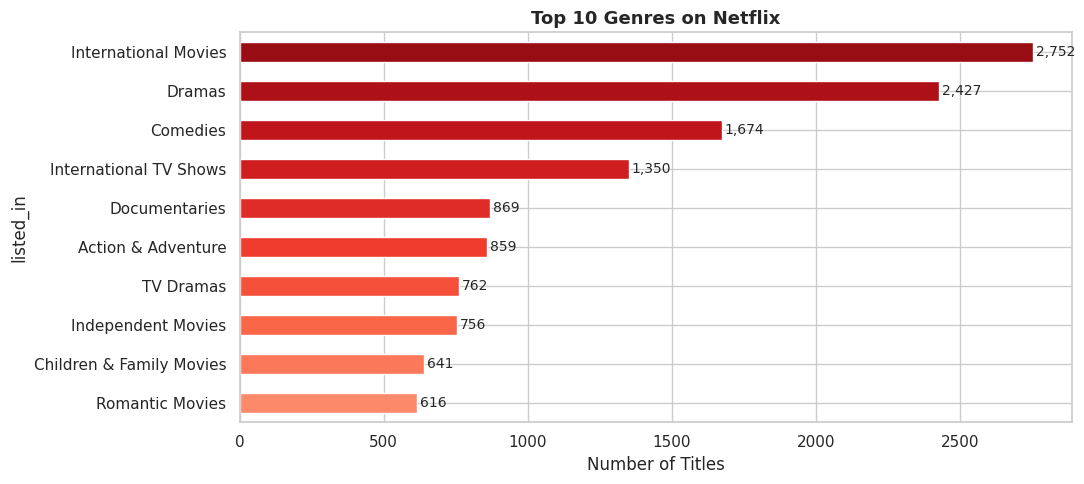

Insight: International Movies and Dramas are the most represented genres.


In [21]:
# Explode multi-genre listings into individual genres
genres = df_clean['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 5))
top_genres[::-1].plot(kind='barh', ax=ax,
                       color=plt.cm.Reds(np.linspace(0.4, 0.9, 10)), edgecolor='white')
ax.set_title('Top 10 Genres on Netflix', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, val in enumerate(top_genres.values[::-1]):
    ax.text(val + 10, i, f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print("Insight: International Movies and Dramas are the most represented genres.")

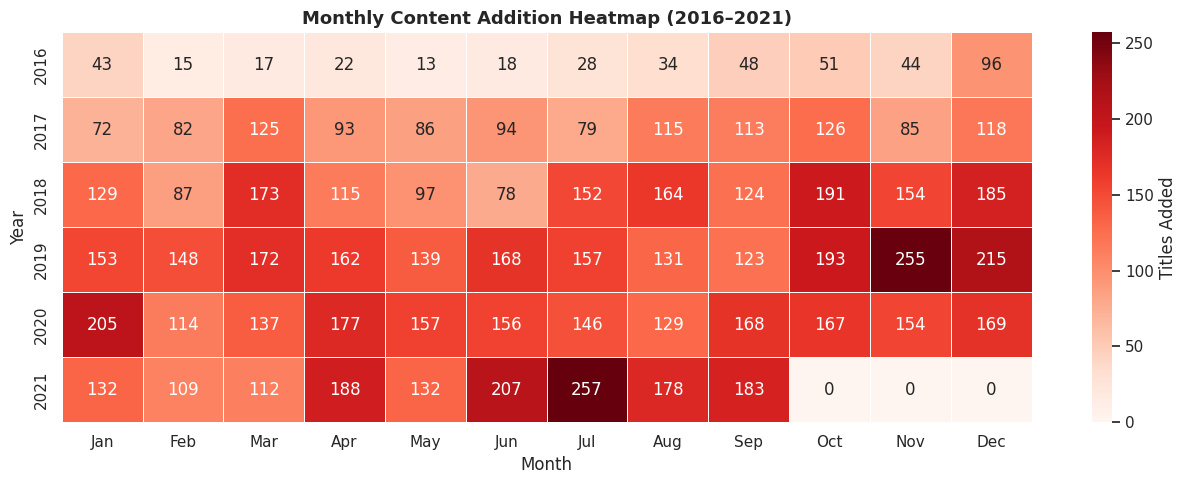

Insight: Netflix adds the most content in Q4 (Oct–Jan), likely ahead of the holiday season.


In [22]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heat_data = df_clean.groupby(['year_added','month_name']).size().unstack(fill_value=0)
# Reorder months
heat_data = heat_data[[m for m in month_order if m in heat_data.columns]]
heat_data = heat_data[heat_data.index >= 2016]  # Focus on main growth years

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heat_data, cmap='Reds', linewidths=0.5, linecolor='white',
            annot=True, fmt='d', ax=ax, cbar_kws={'label': 'Titles Added'})
ax.set_title('Monthly Content Addition Heatmap (2016–2021)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

print("Insight: Netflix adds the most content in Q4 (Oct–Jan), likely ahead of the holiday season.")

In [23]:
print("""
           Data Visualization — Key Insights

  1. Netflix has 6,131 Movies (70%) vs 2,676 TV Shows (30%).

  2. Content growth peaked in 2019 with ~2,000 titles added.

  3. USA leads production (2,818 titles), India is 2nd (972).

  4. TV-MA is the dominant rating — Netflix skews adult.

  5. Average movie runtime is ~100 minutes.

  6. International Movies & Dramas are top genres.

  7. Most content is added in Q4 (Oct–Jan) each year.

""")



           Data Visualization — Key Insights                  
                                                              
  1. Netflix has 6,131 Movies (70%) vs 2,676 TV Shows (30%). 
                                                              
  2. Content growth peaked in 2019 with ~2,000 titles added. 
                                                              
  3. USA leads production (2,818 titles), India is 2nd (972).
                                                              
  4. TV-MA is the dominant rating — Netflix skews adult.      
                                                              
  5. Average movie runtime is ~100 minutes.                   
                                                            
  6. International Movies & Dramas are top genres.           
                                                              
  7. Most content is added in Q4 (Oct–Jan) each year.        
                                                             